# EDA тестовых кропов

Размеры, аспекты, режимы, контакт-лист случайных примеров. Seed фиксирован.

In [6]:
# Данные: <ROOT>/sample_submission.csv, <ROOT>/test/images/*.png
import os, sys, subprocess
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src").is_dir())
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

from src.env import setup
P = setup(ROOT)
print({k: str(v) for k, v in P.items()})


[env] /app/sample_submission.csv not found -> ids will be taken from the images folder
{'root': '/app', 'images': '/app/test/images', 'sample_submission': 'None', 'outputs': '/app/outputs', 'weights': '/app/weights'}


In [7]:
import random
import numpy as np
from PIL import Image

SEED = 42
random.seed(SEED)

files = sorted(P["images"].glob("*.png"))
print(len(files), "images")

ws, hs, modes = [], [], {}
for f in files:
    with Image.open(f) as im:
        ws.append(im.width)
        hs.append(im.height)
        modes[im.mode] = modes.get(im.mode, 0) + 1
ws, hs = np.array(ws), np.array(hs)
ar = ws / hs
print("modes", modes)
for name, a in [("width", ws), ("height", hs), ("aspect w/h", ar)]:
    q = np.percentile(a, [5, 25, 50, 75, 95])
    print(f"{name}: min={a.min():.1f} p5={q[0]:.1f} p25={q[1]:.1f} med={q[2]:.1f} p75={q[3]:.1f} p95={q[4]:.1f} max={a.max():.1f}")
print("vertical (h>w):", (hs > ws).mean(), " tall (h>1.5w):", (hs > 1.5 * ws).mean())

20000 images
modes {'RGB': 20000}
width: min=25.0 p5=61.0 p25=129.0 med=238.0 p75=479.2 p95=1047.0 max=1599.0
height: min=10.0 p5=16.0 p25=27.0 med=42.0 p75=76.0 p95=195.0 max=492.0
aspect w/h: min=0.7 p5=2.3 p25=3.5 med=4.9 p75=7.5 p95=14.4 max=49.7
vertical (h>w): 0.0002  tall (h>1.5w): 0.0


['test_03648', 'test_00819', 'test_09012', 'test_08024', 'test_07314', 'test_04572', 'test_03358', 'test_17870', 'test_02848', 'test_19349', 'test_13825', 'test_01041', 'test_00976', 'test_03070', 'test_07164', 'test_07623', 'test_16559', 'test_19726', 'test_00869', 'test_18390', 'test_06515', 'test_17856', 'test_13746', 'test_07223', 'test_14719', 'test_19309', 'test_09115', 'test_00212', 'test_05231', 'test_13848']


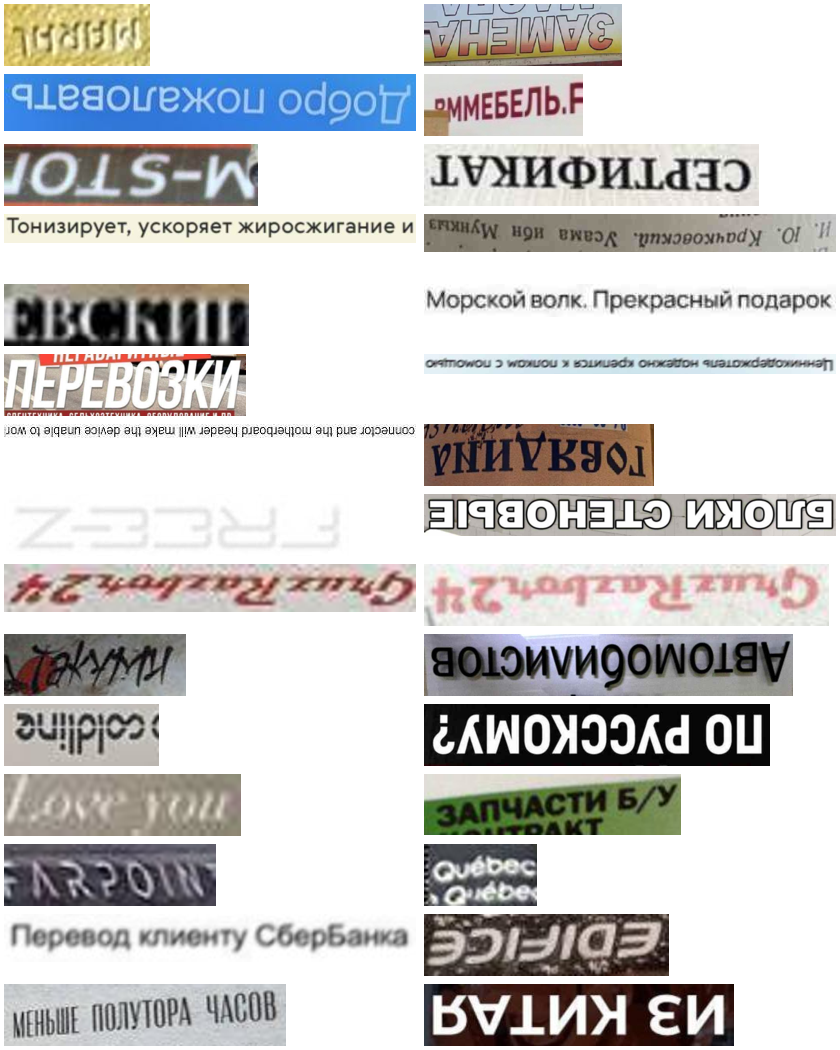

In [8]:
out_dir = P["outputs"] / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
sample = random.sample(files, min(30, len(files)))
W, H = 420, 70
sheet = Image.new("RGB", (W * 2, H * 15), "white")
for i, f in enumerate(sample):
    im = Image.open(f).convert("RGB")
    s = min((W - 8) / im.width, (H - 8) / im.height)
    im = im.resize((max(1, int(im.width * s)), max(1, int(im.height * s))))
    sheet.paste(im, ((i % 2) * W + 4, (i // 2) * H + 4))
sheet.save(out_dir / "sheet.png")
print([f.stem for f in sample])
sheet

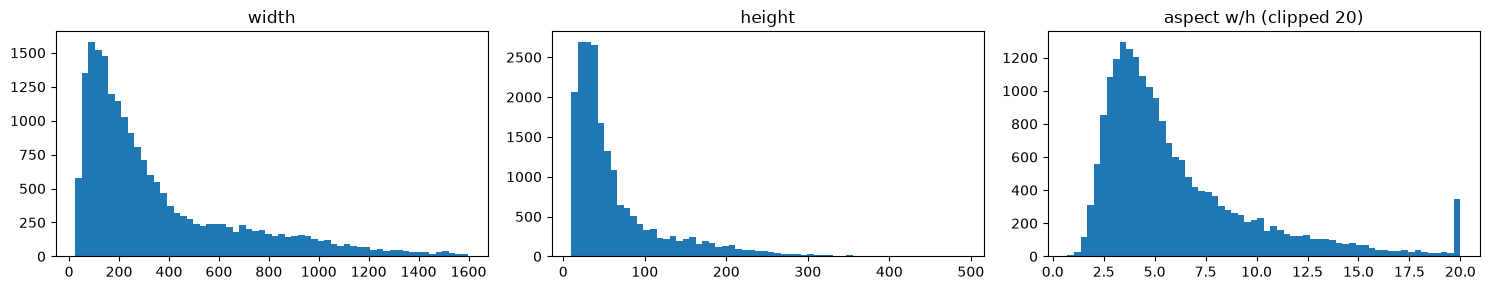

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].hist(ws, bins=60); ax[0].set_title("width")
ax[1].hist(hs, bins=60); ax[1].set_title("height")
ax[2].hist(np.clip(ar, 0, 20), bins=60); ax[2].set_title("aspect w/h (clipped 20)")
plt.tight_layout()
plt.show()